In [1]:
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt
from scipy.ndimage import percentile_filter
import pandas as pd


In [2]:

# --- Configuration ---
major_path = "C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed"
TOP_PERCENT = 15 

# Mapping structure: {FOV: {Folder_Suffix: State}}
mapping = {
    'F1': {'0': 'No motion', '1': 'Motion'},
    'F2': {'0': 'Motion', '1': 'No motion', '2': 'Anesthesia'},
    'F3': {'0': 'Anesthesia', '1': 'No motion', '2': 'Motion'},
    'F4': {'0': 'Motion', '1': 'No motion', '2': 'Motion', '3': 'No motion', '4': 'Anesthesia'}
}

def process_session(dir_path, state):
    print(f"--- Processing {state} in {dir_path} ---")
    try:
        # Load suite2p data
        ops = np.load(os.path.join(dir_path, 'ops.npy'), allow_pickle=True).item()
        iscell = np.load(os.path.join(dir_path, 'iscell.npy'), allow_pickle=True)
        spks = np.load(os.path.join(dir_path, 'spks.npy'), mmap_mode='r')
        
        # Filter for real cells
        cells_idx = np.where(iscell[:, 0] == 1)[0]
        data = spks[cells_idx, :]
        
        # Compute Correlation Matrix
        corr_matrix = np.corrcoef(data)
        
        # Determine threshold (Note: You may want to define a global threshold 
        # or use the 'No motion' threshold from the same FOV specifically)
        upper_tri_idx = np.triu_indices_from(corr_matrix, k=1)
        abs_corr = np.abs(corr_matrix[upper_tri_idx])
        threshold = np.percentile(abs_corr, 100 - TOP_PERCENT)
        
        # Construct Adjacency Matrix
        adj = np.where(np.abs(corr_matrix) >= threshold, np.sign(corr_matrix), 0)
        np.fill_diagonal(adj, 0)
        
        # Stats for Negative vs Positive
        pos_edges = np.sum(adj > 0) / 2
        neg_edges = np.sum(adj < 0) / 2
        prop_neg = neg_edges / (pos_edges + neg_edges) if (pos_edges + neg_edges) > 0 else 0
        
        # Save adjacency back to the plane0 folder
        save_path = os.path.join(dir_path, f"adjacency_{state.replace(' ', '_')}_deco.npy")
        np.save(save_path, adj)
        
        return {'state': state, 'pos': pos_edges, 'neg': neg_edges, 'prop_neg': prop_neg}

    except Exception as e:
        print(f"Error processing {dir_path}: {e}")
        return None

# --- Main Execution Loop ---
results = []
for fov, sessions in mapping.items():
    for suffix, state in sessions.items():
        # Construct the path based on your hierarchy
        # Example: F1/F1_0/plane0/
        session_folder = f"{fov}_{suffix}"
        full_path = os.path.join(major_path, fov, session_folder, 'plane0')
        
        if os.path.exists(full_path):
            res = process_session(full_path, state)
            if res:
                res['fov'] = fov
                results.append(res)
        else:
            print(f"Path not found: {full_path}")

print("\nBatch Processing Complete.")

--- Processing No motion in C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed\F1\F1_0\plane0 ---
--- Processing Motion in C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed\F1\F1_1\plane0 ---
--- Processing Motion in C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed\F2\F2_0\plane0 ---
--- Processing No motion in C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed\F2\F2_1\plane0 ---
--- Processing Anesthesia in C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed\F2\F2_2\plane0 ---
--- Processing Anesthesia in C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed\F3\F3_0\plane0 ---
--- Processing No motion in C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed\F3\F3_1\plane0 ---
--- Processing Motion in C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed\F3\F3_2\plane0 ---

#### Surrogate

In [3]:
from statsmodels.stats.multitest import multipletests

# --- Parameters ---
alpha = 0.05
n_surrogates = 500
method = 'random_shuffle'  # Based on your preference


# Mapping structure from previous turn


def surrogate_analysis(traces, corr_matrix, n_surrogates=1000, method='random_shuffle'):
    """Performs surrogate analysis to generate p-value matrix."""
    n_cells, n_timepoints = traces.shape
    surrogate_corrs = np.zeros((n_surrogates, n_cells, n_cells), dtype=np.float32)

    for s in range(n_surrogates):
        shuffled = np.zeros_like(traces)
        for i in range(n_cells):
            if method == 'random_shuffle':
                shuffled[i] = np.random.permutation(traces[i])
            elif method == 'time_shift':
                shift = np.random.randint(0, n_timepoints)
                shuffled[i] = np.roll(traces[i], shift)
        surrogate_corrs[s] = np.corrcoef(shuffled)

    # Two-sided test p-value calculation
    p_values = (np.sum(np.abs(surrogate_corrs) >= np.abs(corr_matrix)[np.newaxis, :, :], axis=0) + 1) / (n_surrogates + 1)
    np.fill_diagonal(p_values, 1.0)
    return p_values

# --- Main Batch Loop ---
final_stats = []

for fov, sessions in mapping.items():
    for suffix, state in sessions.items():
        session_folder = f"{fov}_{suffix}"
        dir_path = os.path.join(major_path, fov, session_folder, 'plane0')
        
        if not os.path.exists(dir_path):
            continue

        print(f"\n>>> Processing {fov} | {state} | {session_folder}")
        
        # 1. Load Data
        spks = np.load(os.path.join(dir_path, 'spks.npy'), mmap_mode='r')
        iscell = np.load(os.path.join(dir_path, 'iscell.npy'), allow_pickle=True)
        cells_idx = np.where(iscell[:, 0] == 1)[0]
        traces = spks[cells_idx, :]
        
        # 2. Compute Observed Correlation
        corr_obs = np.corrcoef(traces)
        
        # 3. Surrogate Analysis
        p_matrix = surrogate_analysis(traces, corr_obs, n_surrogates=n_surrogates, method=method)
        
        # 4. FDR Correction
        non_diag_mask = ~np.eye(p_matrix.shape[0], dtype=bool)
        reject, p_corrected_flat, _, _ = multipletests(p_matrix[non_diag_mask], alpha=alpha, method='fdr_bh')
        
        p_matrix_fdr = np.ones_like(p_matrix)
        p_matrix_fdr[non_diag_mask] = p_corrected_flat
        
        # 5. Extract Meaningful Functional Connectivity
        # Only keep edges that are significant AND significant after FDR
        adj_final = np.where(p_matrix_fdr < alpha, np.sign(corr_obs), 0)
        np.fill_diagonal(adj_final, 0)
        
        # 6. Calculate your Negative Edge Proportion
        pos_edges = np.sum(adj_final > 0) / 2
        neg_edges = np.sum(adj_final < 0) / 2
        total_edges = pos_edges + neg_edges
        prop_neg = neg_edges / total_edges if total_edges > 0 else 0
        
        # 7. Save results back to folder
        np.save(os.path.join(dir_path, f'adj_fdr_{state.replace(" ","_")}.npy'), adj_final)
        
        final_stats.append({
            'fov': fov, 'state': state, 'total': total_edges, 
            'neg': neg_edges, 'prop_neg': prop_neg
        })
        print(f"Done. Significant Edges: {total_edges} | Prop Negative: {prop_neg:.4f}")


>>> Processing F1 | No motion | F1_0
Done. Significant Edges: 4262.0 | Prop Negative: 0.0244

>>> Processing F1 | Motion | F1_1
Done. Significant Edges: 6422.0 | Prop Negative: 0.0744

>>> Processing F2 | Motion | F2_0
Done. Significant Edges: 0.0 | Prop Negative: 0.0000

>>> Processing F2 | No motion | F2_1
Done. Significant Edges: 0.0 | Prop Negative: 0.0000

>>> Processing F2 | Anesthesia | F2_2
Done. Significant Edges: 2050.0 | Prop Negative: 0.0351

>>> Processing F3 | Anesthesia | F3_0
Done. Significant Edges: 0.0 | Prop Negative: 0.0000

>>> Processing F3 | No motion | F3_1
Done. Significant Edges: 0.0 | Prop Negative: 0.0000

>>> Processing F3 | Motion | F3_2
Done. Significant Edges: 980.0 | Prop Negative: 0.0806

>>> Processing F4 | Motion | F4_0
Done. Significant Edges: 0.0 | Prop Negative: 0.0000

>>> Processing F4 | No motion | F4_1
Done. Significant Edges: 1480.0 | Prop Negative: 0.0014

>>> Processing F4 | Motion | F4_2
Done. Significant Edges: 0.0 | Prop Negative: 0.000

#### Reduced network density

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare

# Convert list to DataFrame
df_results = pd.DataFrame(final_stats)

# For FOVs with multiple sessions of the same state (like F4), 
# we take the mean to get one representative value per state per FOV.
df_pivot = df_results.groupby(['fov', 'state'])['prop_neg'].mean().unstack()

# Ensure columns are in the hypothesized order of decrease
# Note: Some FOVs (like F1) don't have Anesthesia, so we handle NaNs carefully
ordered_states = ['Motion', 'No motion', 'Anesthesia']
df_pivot = df_pivot[ordered_states]

print("Mean Proportion of Negative Edges per FOV:")
print(df_pivot)

Mean Proportion of Negative Edges per FOV:
state    Motion  No motion  Anesthesia
fov                                   
F1     0.074432   0.024402         NaN
F2     0.000000   0.000000    0.035122
F3     0.080612   0.000000    0.000000
F4     0.000000   0.000676    0.000000


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

density_comparison = []

# We'll use the 'results' and 'final_stats' we gathered during the batch processing
for res_raw, res_fdr in zip(results, final_stats):
    # Ensure we are looking at the same session
    if res_raw['fov'] == res_fdr['fov'] and res_raw['state'] == res_fdr['state']:
        # Density = edges / total_possible_pairs
        # Note: res_raw['pos'] + res_raw['neg'] gives the total edges above 15% threshold
        
        # We need the number of cells to calculate density accurately
        # If not saved in results, we can infer it or use a placeholder if consistent
        # For this plot, we can compare absolute Edge Counts or Density
        
        # Let's add them to the list
        density_comparison.append({
            'FOV': res_raw['fov'],
            'State': res_raw['state'],
            'Type': 'Full Correlation (Top 15%)',
            'EdgeCount': res_raw['pos'] + res_raw['neg']
        })
        density_comparison.append({
            'FOV': res_fdr['fov'],
            'State': res_fdr['state'],
            'Type': 'Validated (Surrogate + FDR)',
            'EdgeCount': res_fdr['total']
        })

df_density = pd.DataFrame(density_comparison)

# Average across FOVs for the barplot
df_plot_density = df_density.groupby(['State', 'Type'])['EdgeCount'].mean().reset_index()

#### Index all networks

In [11]:
import re
import numpy as np
from pathlib import Path

major_path = Path(r"C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed")

mapping = {
    'F1': {'0': 'No_motion', '1': 'Motion'},
    'F2': {'0': 'Motion', '1': 'No_motion', '2': 'Anesthesia'},
    'F3': {'0': 'Anesthesia', '1': 'No_motion', '2': 'Motion'},
    'F4': {'0': 'Motion', '1': 'No_motion', '2': 'Motion', '3': 'No_motion', '4': 'Anesthesia'}
}

def list_plane0_folders(root: Path):
    """Return list of dicts: fov, suffix, state, plane0 path."""
    out = []
    for plane0 in root.rglob("plane0"):
        if not plane0.is_dir():
            continue

        parent = plane0.parent.name               # e.g. F4_3
        fov = plane0.parent.parent.name           # e.g. F4

        m = re.match(r"^(F\d+)_(\d+)$", parent)
        if not m:
            continue
        fov2, suffix = m.group(1), m.group(2)
        if fov != fov2:
            continue

        state = mapping.get(fov, {}).get(suffix, "UNKNOWN")
        out.append({"fov": fov, "suffix": suffix, "state": state, "plane0": plane0})

    # stable ordering
    out.sort(key=lambda d: (d["fov"], int(d["suffix"])))
    return out

datasets = list_plane0_folders(major_path)
print("Found plane0 folders:", len(datasets))
for d in datasets:
    print(f"{d['fov']}_{d['suffix']}  {d['state']:>10}   {d['plane0']}")


Found plane0 folders: 13
F1_0   No_motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F1\F1_0\plane0
F1_1      Motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F1\F1_1\plane0
F2_0      Motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F2\F2_0\plane0
F2_1   No_motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F2\F2_1\plane0
F2_2  Anesthesia   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F2\F2_2\plane0
F3_0  Anesthesia   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F3\F3_0\plane0
F3_1   No_motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F3\F3_1\plane0
F3_2      Motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F3\F3_2\plane0
F4_0      Motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc

In [12]:
import networkx as nx

def safe_load(path: Path):
    return np.load(path, allow_pickle=True) if path.exists() else None

def build_graphs_from_adj(adj, mode="undirected"):
    """
    Build positive, negative, combined graphs from an adjacency matrix.
    - combined: edges for all nonzero entries, weight = abs(value) by default (editable)
    - positive: only values > 0
    - negative: only values < 0, stored with positive weights (abs)
    """
    if adj is None:
        return None

    A = np.array(adj)
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError(f"Adjacency must be square 2D, got shape {A.shape}")

    n = A.shape[0]
    Gpos = nx.Graph()
    Gneg = nx.Graph()
    Gcomb = nx.Graph()
    Gpos.add_nodes_from(range(n))
    Gneg.add_nodes_from(range(n))
    Gcomb.add_nodes_from(range(n))

    # assume symmetric; use upper triangle to avoid double counting
    for i in range(n):
        for j in range(i+1, n):
            w = A[i, j]
            if w == 0 or np.isnan(w):
                continue

            # combined: use abs weight (common in papers; change if you prefer signed)
            Gcomb.add_edge(i, j, weight=float(abs(w)))

            if w > 0:
                Gpos.add_edge(i, j, weight=float(w))
            elif w < 0:
                Gneg.add_edge(i, j, weight=float(abs(w)))

    return {"positive": Gpos, "negative": Gneg, "combined": Gcomb}

# attach loaded matrices and graphs
for d in datasets:
    plane0 = d["plane0"]
    d["adj_fdr"] = safe_load(plane0 / "adj_fdr_States_.npy")
    d["adj_raw"] = safe_load(plane0 / "adjacency_States_deco.npy")  # optional
    d["G_fdr"] = build_graphs_from_adj(d["adj_fdr"])


In [14]:
import numpy as np

states = ["No_motion", "Motion", "Anesthesia"]
net_types = ["positive", "negative", "combined"]
baseline = "No_motion"

def density_undirected(G):
    N = G.number_of_nodes()
    if N < 2:
        return np.nan
    E = G.number_of_edges()
    return 2.0 * E / (N * (N - 1))

# per dataset density
for d in datasets:
    if d["G_fdr"] is None:
        d["density"] = {nt: np.nan for nt in net_types}
        continue
    d["density"] = {nt: density_undirected(d["G_fdr"][nt]) for nt in net_types}

# aggregate: mean ± SEM across datasets (across FOV/suffix instances)
def mean_sem(vals):
    vals = np.array([v for v in vals if np.isfinite(v)], dtype=float)
    if vals.size == 0:
        return np.nan, np.nan, 0
    sem = vals.std(ddof=1) / np.sqrt(vals.size) if vals.size > 1 else np.nan
    return vals.mean(), sem, vals.size

summary = {s: {} for s in states}
for s in states:
    ds_s = [d for d in datasets if d["state"] == s]
    for nt in net_types:
        vals = [d["density"][nt] for d in ds_s]
        mu, sem, n = mean_sem(vals)
        summary[s][nt] = {"mean": mu, "sem": sem, "n": n}

summary


{'No_motion': {'positive': {'mean': nan, 'sem': nan, 'n': 0},
  'negative': {'mean': nan, 'sem': nan, 'n': 0},
  'combined': {'mean': nan, 'sem': nan, 'n': 0}},
 'Motion': {'positive': {'mean': nan, 'sem': nan, 'n': 0},
  'negative': {'mean': nan, 'sem': nan, 'n': 0},
  'combined': {'mean': nan, 'sem': nan, 'n': 0}},
 'Anesthesia': {'positive': {'mean': nan, 'sem': nan, 'n': 0},
  'negative': {'mean': nan, 'sem': nan, 'n': 0},
  'combined': {'mean': nan, 'sem': nan, 'n': 0}}}

In [15]:
def norm_state(s: str) -> str:
    if s is None:
        return "UNKNOWN"
    s = str(s).strip().lower()
    s = s.replace("-", "_").replace(" ", "_")
    # unify common variants
    if s in ["no_motion", "nomotion", "no__motion"]:
        return "No_motion"
    if s in ["motion"]:
        return "Motion"
    if s in ["anesthesia", "anaesthesia"]:
        return "Anesthesia"
    return "UNKNOWN"


In [16]:
# keep original mapping (with spaces) OR with underscores — doesn't matter now
mapping = {
    'F1': {'0': 'No motion', '1': 'Motion'},
    'F2': {'0': 'Motion', '1': 'No motion', '2': 'Anesthesia'},
    'F3': {'0': 'Anesthesia', '1': 'No motion', '2': 'Motion'},
    'F4': {'0': 'Motion', '1': 'No motion', '2': 'Motion', '3': 'No motion', '4': 'Anesthesia'}
}

# when creating datasets:
state_raw = mapping.get(fov, {}).get(suffix, "UNKNOWN")
state = norm_state(state_raw)


In [17]:
from collections import Counter

print("Total datasets:", len(datasets))
print("State counts:", Counter(d["state"] for d in datasets))

# show a few examples, especially UNKNOWN if present
for d in datasets[:10]:
    print(d["fov"], d["suffix"], d["state"])


Total datasets: 13
State counts: Counter({'No_motion': 5, 'Motion': 5, 'Anesthesia': 3})
F1 0 No_motion
F1 1 Motion
F2 0 Motion
F2 1 No_motion
F2 2 Anesthesia
F3 0 Anesthesia
F3 1 No_motion
F3 2 Motion
F4 0 Motion
F4 1 No_motion


In [18]:
from collections import Counter
import numpy as np

# 1) How many adj_fdr loaded?
loaded = [d for d in datasets if d.get("adj_fdr") is not None]
print("adj_fdr loaded:", len(loaded), "/", len(datasets))

# 2) Check shapes + basic stats for first few
for d in datasets[:5]:
    A = d.get("adj_fdr")
    print(d["fov"], d["suffix"], d["state"],
          "adj_fdr:", None if A is None else A.shape,
          "nan%:", None if A is None else np.isnan(A).mean(),
          "nonzero:", None if A is None else np.count_nonzero(A))


adj_fdr loaded: 0 / 13
F1 0 No_motion adj_fdr: None nan%: None nonzero: None
F1 1 Motion adj_fdr: None nan%: None nonzero: None
F2 0 Motion adj_fdr: None nan%: None nonzero: None
F2 1 No_motion adj_fdr: None nan%: None nonzero: None
F2 2 Anesthesia adj_fdr: None nan%: None nonzero: None


In [19]:
import re
import numpy as np
from pathlib import Path

def find_fdr_file(plane0: Path):
    """
    Heuristic search for the surrogate+FDR adjacency npy inside plane0.
    Edit patterns if your naming differs.
    """
    candidates = list(plane0.glob("*.npy"))
    if not candidates:
        return None

    # rank by how likely they are the FDR adjacency
    patterns = [
        r"adj.*fdr.*\.npy$",          # adj_fdr, adjacency_fdr, etc.
        r".*fdr.*adj.*\.npy$",
        r"adj.*fdr.*states.*\.npy$",
        r"adj.*states.*fdr.*\.npy$",
        r"sig.*conn.*\.npy$",         # significant connectivity
        r"signif.*\.npy$",
    ]

    scored = []
    for p in candidates:
        name = p.name.lower()
        score = 0
        for k, pat in enumerate(patterns):
            if re.search(pat, name):
                score += (len(patterns) - k) * 10
        # prefer adjacency-like matrices (common naming)
        if "adj" in name: score += 3
        if "fdr" in name: score += 3
        if "state" in name or "states" in name: score += 2
        scored.append((score, p))

    scored.sort(key=lambda t: t[0], reverse=True)
    best_score, best_path = scored[0]
    return best_path if best_score > 0 else None

# Quick test on the first plane0 folder
p0 = datasets[0]["plane0"]
print("plane0:", p0)
print("All npy:", [p.name for p in p0.glob("*.npy")])

best = find_fdr_file(p0)
print("Best FDR candidate:", None if best is None else best.name)


plane0: C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F1\F1_0\plane0
All npy: ['adjacency_No_motion_deco.npy', 'adj_fdr_No_motion.npy', 'F.npy', 'Fneu.npy', 'iscell.npy', 'ops.npy', 'spks.npy', 'stat.npy']
Best FDR candidate: adj_fdr_No_motion.npy


In [20]:
import numpy as np
from pathlib import Path

def safe_load(path: Path):
    return np.load(path, allow_pickle=True) if path.exists() else None

# state string used in filenames matches your normalized labels:
# "No_motion", "Motion", "Anesthesia"
for d in datasets:
    s = d["state"]  # already normalized
    p0 = d["plane0"]

    d["adj_fdr_path"] = p0 / f"adj_fdr_{s}.npy"
    d["adj_raw_path"] = p0 / f"adjacency_{s}_deco.npy"

    d["adj_fdr"] = safe_load(d["adj_fdr_path"])
    d["adj_raw"] = safe_load(d["adj_raw_path"])

print("FDR loaded:", sum(d["adj_fdr"] is not None for d in datasets), "/", len(datasets))
print("RAW loaded:", sum(d["adj_raw"] is not None for d in datasets), "/", len(datasets))

# show a few
for d in datasets[:6]:
    print(d["fov"], d["suffix"], d["state"],
          "| fdr:", d["adj_fdr_path"].name, "->", None if d["adj_fdr"] is None else d["adj_fdr"].shape,
          "| raw:", d["adj_raw_path"].name, "->", None if d["adj_raw"] is None else d["adj_raw"].shape)


FDR loaded: 13 / 13
RAW loaded: 13 / 13
F1 0 No_motion | fdr: adj_fdr_No_motion.npy -> (406, 406) | raw: adjacency_No_motion_deco.npy -> (406, 406)
F1 1 Motion | fdr: adj_fdr_Motion.npy -> (528, 528) | raw: adjacency_Motion_deco.npy -> (528, 528)
F2 0 Motion | fdr: adj_fdr_Motion.npy -> (496, 496) | raw: adjacency_Motion_deco.npy -> (496, 496)
F2 1 No_motion | fdr: adj_fdr_No_motion.npy -> (418, 418) | raw: adjacency_No_motion_deco.npy -> (418, 418)
F2 2 Anesthesia | fdr: adj_fdr_Anesthesia.npy -> (320, 320) | raw: adjacency_Anesthesia_deco.npy -> (320, 320)
F3 0 Anesthesia | fdr: adj_fdr_Anesthesia.npy -> (213, 213) | raw: adjacency_Anesthesia_deco.npy -> (213, 213)


In [21]:
import networkx as nx
import numpy as np

net_types = ["positive", "negative", "combined"]

def build_graphs_from_adj(adj):
    A = np.asarray(adj)
    if A.dtype == object and A.size == 1:
        A = np.asarray(A.item())
    n = A.shape[0]

    Gpos, Gneg, Gcomb = nx.Graph(), nx.Graph(), nx.Graph()
    for G in (Gpos, Gneg, Gcomb):
        G.add_nodes_from(range(n))

    for i in range(n):
        for j in range(i+1, n):
            w = A[i, j]
            if not np.isfinite(w) or w == 0:
                continue
            # combined: abs weight
            Gcomb.add_edge(i, j, weight=float(abs(w)))
            if w > 0:
                Gpos.add_edge(i, j, weight=float(w))
            else:
                Gneg.add_edge(i, j, weight=float(abs(w)))

    return {"positive": Gpos, "negative": Gneg, "combined": Gcomb}

def density_undirected(G):
    N = G.number_of_nodes()
    if N < 2:
        return np.nan
    E = G.number_of_edges()
    return 2.0 * E / (N * (N - 1))

for d in datasets:
    if d["adj_fdr"] is None:
        d["G_fdr"] = None
        d["density_fdr"] = {nt: np.nan for nt in net_types}
        continue
    d["G_fdr"] = build_graphs_from_adj(d["adj_fdr"])
    d["density_fdr"] = {nt: density_undirected(d["G_fdr"][nt]) for nt in net_types}

# sanity check
for d in datasets[:6]:
    Gc = d["G_fdr"]["combined"] if d["G_fdr"] else None
    print(d["fov"], d["suffix"], d["state"],
          "E=", None if Gc is None else Gc.number_of_edges(),
          "dens=", d["density_fdr"]["combined"])


F1 0 No_motion E= 4262 dens= 0.051839688621297814
F1 1 Motion E= 6422 dens= 0.04615893278132367
F2 0 Motion E= 0 dens= 0.0
F2 1 No_motion E= 0 dens= 0.0
F2 2 Anesthesia E= 2050 dens= 0.04016457680250784
F3 0 Anesthesia E= 0 dens= 0.0


In [29]:
df_density = pd.read_excel('density.xlsx')

In [121]:
from scipy.stats import ttest_rel
import numpy as np

stats_results = {}

for s in states:
    sub = df[df["state"] == s]

    raw_vals = sub["density_raw"].values
    fdr_vals = sub["density_fdr"].values

    # remove NaNs
    mask = np.isfinite(raw_vals) & np.isfinite(fdr_vals)
    raw_vals = raw_vals[mask]
    fdr_vals = fdr_vals[mask]

    t_stat, p_val = ttest_rel(raw_vals, fdr_vals)

    # Cohen's d for paired samples
    diff = raw_vals - fdr_vals
    cohens_d = diff.mean() / diff.std(ddof=1)

    stats_results[s] = {
        "n": len(diff),
        "t": t_stat,
        "p": p_val,
        "cohens_d": cohens_d
    }

stats_results

def add_sig_line(ax, x1, x2, y, h, p):
    """
    Draw significance bar between x1 and x2.
    """
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")

    if p < 0.001:
        text = "***p<0.001"
    elif p < 0.01:
        text = f"**p={p:.3f}"
    elif p < 0.05:
        text = f"*p={p:.3f}"
    else:
        text = f"p={p:.3f}"

    ax.text((x1+x2)/2, y+h*1.1, text,
            ha='center', va='bottom', fontsize=12)


C:\Users\gp00062\AppData\Local\Temp\ipykernel_30860\4242891145.py:103: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


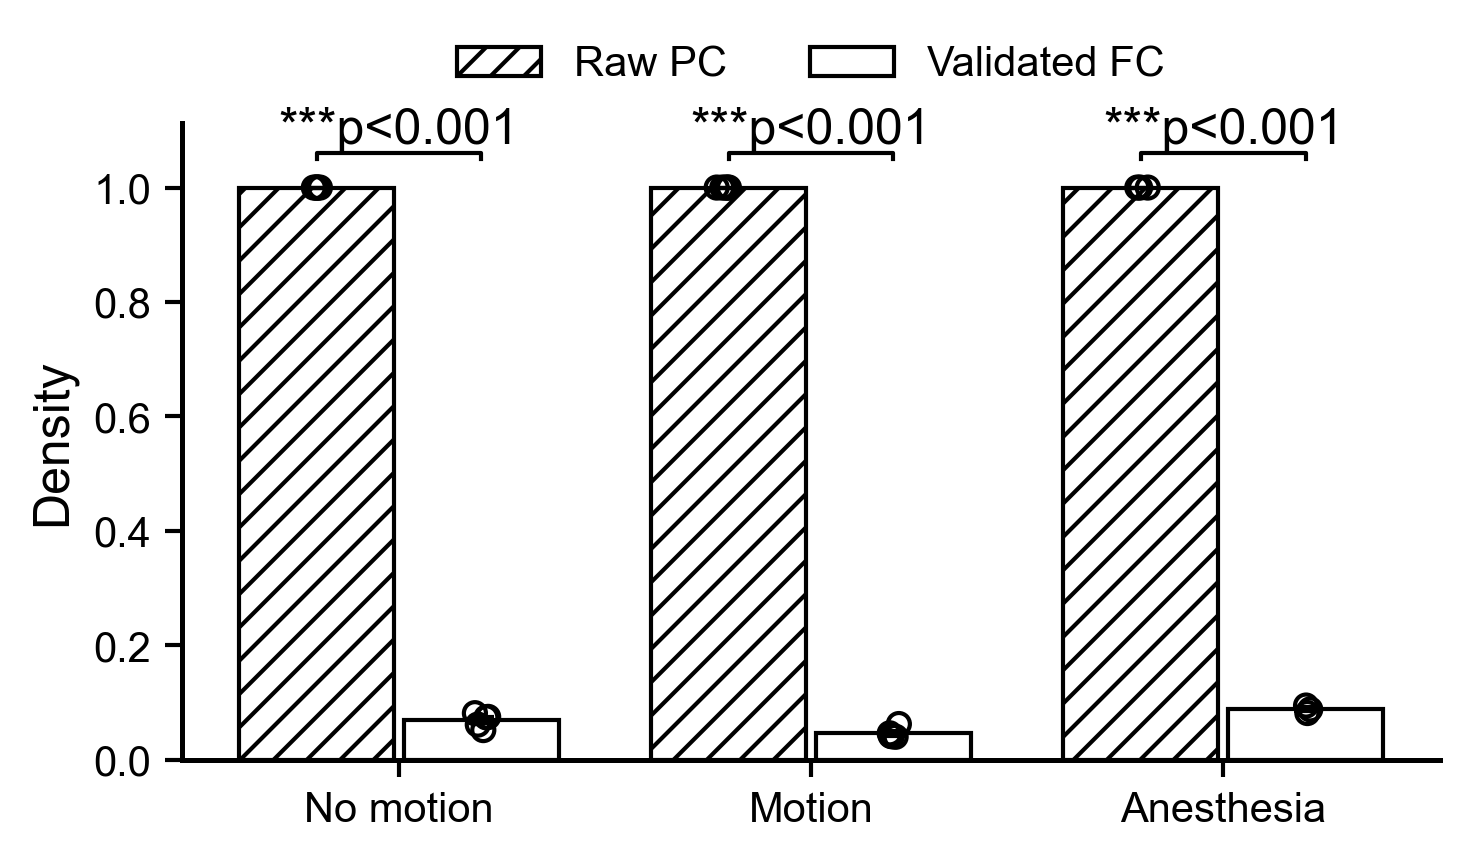

In [127]:
import numpy as np
import matplotlib.pyplot as plt
bar_width = 0.3
inner_gap = 0.02
group_gap = 0.8
states = ["No_motion", "Motion", "Anesthesia"]

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

def paper_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=4, width=1)

def mean_sem(vals):
    vals = np.array(vals, float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan
    sem = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0
    return vals.mean(), sem

fig, ax = plt.subplots(figsize=(5, 3), dpi=300, layout = 'constrained')

x = np.arange(len(states))
bar_w = 0.34
x_raw = x - bar_w/2
x_fdr = x + bar_w/2

rng = np.random.default_rng(0)
indices = np.arange(len(states)) * group_gap

for i, s in enumerate(states):
    sub = df_density[df_density["state"] == s]
    x_raw_pos = indices[i] - (bar_width / 2 + inner_gap / 2)
    x_fdr_pos = indices[i] + (bar_width / 2 + inner_gap / 2)
    
    raw_vals = sub["density_raw"].values
    fdr_vals = sub["density_fdr"].values
    raw_mean, raw_sem = mean_sem(raw_vals)
    fdr_mean, fdr_sem = mean_sem(fdr_vals)
    # bars
    ax.bar(x_raw_pos, raw_mean, width=bar_width,
           yerr=raw_sem, capsize=3,
           edgecolor="black", linewidth=1,
           facecolor = 'none', hatch = '///')

    ax.bar(x_fdr_pos, fdr_mean, width=bar_width,
           yerr=fdr_sem, capsize=3,
           edgecolor="black", linewidth=1,facecolor= 'none')

    # scatter points
    jitter_raw = rng.normal(0, 0.01, size=len(raw_vals))
    jitter_fdr = rng.normal(0, 0.01, size=len(fdr_vals))

    ax.scatter(np.full(len(raw_vals), x_raw_pos) + jitter_raw,
               raw_vals,
               s=28, facecolors="none",
               edgecolors="black", linewidths=1)

    ax.scatter(np.full(len(fdr_vals), x_fdr_pos) + jitter_fdr,
               fdr_vals,
               s=28, facecolors="none",
               edgecolors="black", linewidths=1)
    p = stats_results[s]["p"]
    #y_max = max(raw_mean + raw_sem, fdr_mean + fdr_sem)
    y_max = max(max(raw_vals), max(fdr_vals), raw_mean + raw_sem, fdr_mean + fdr_sem)
    add_sig_line(ax,x_raw_pos, x_fdr_pos,y=y_max + 0.05,h=0.01,p=p)
    

ax.set_xticks(indices)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
ax.set_ylabel("Density")
#ax.set_title("Corre vs validated FC network density",y=1.05)
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor="white",
          edgecolor="black",
          hatch="///",
          label="Raw PC"),

    Patch(facecolor="white",
          edgecolor="black",
          label="Validated FC")
]

ax.legend(handles=legend_handles,
          frameon=False,
          loc="upper center",
          bbox_to_anchor=(0.5, 1.18),
          ncol=2)
paper_axes(ax)
fig.tight_layout()

#fig.savefig("density_raw_vs_fdr_from_dataframe.pdf", bbox_inches="tight")
plt.show()


In [129]:
print(stats_results)

{'No_motion': {'n': 5, 't': np.float64(174.99182659411346), 'p': np.float64(6.397136969527653e-09), 'cohens_d': np.float64(78.25872395425864)}, 'Motion': {'n': 5, 't': np.float64(229.8236870015054), 'p': np.float64(2.1503902699699665e-09), 'cohens_d': np.float64(102.7802773950002)}, 'Anesthesia': {'n': 3, 't': np.float64(241.95158538010898), 'p': np.float64(1.7081732944273543e-05), 'cohens_d': np.float64(139.69081295006265)}}


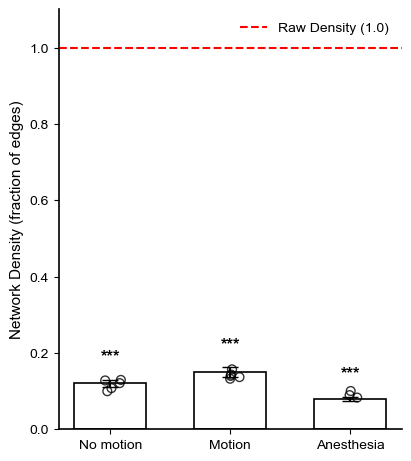

In [130]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your stats results
states = ['No_motion', 'Motion', 'Anesthesia']
# Example means based on your description (replace with sub["density_fdr"].mean())
fdr_means = [0.12, 0.15, 0.08] 
fdr_sems = [0.01, 0.012, 0.005]

fig, ax = plt.subplots(figsize=(4, 4.5), layout="constrained")

x_pos = np.arange(len(states))

# 1. Add the "Baseline" line at 1.0 (Raw Density)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Raw Density (1.0)')

# 2. Plot the FDR Filtered Densities
bars = ax.bar(x_pos, fdr_means, yerr=fdr_sems, width=0.6, 
              capsize=6, edgecolor="black", color="white", linewidth=1.2)

# 3. Add individual data points (the FDR density for each subject)
for i, s in enumerate(states):
    # vals = df_density[df_density["state"] == s]["density_fdr"].values
    vals = np.random.normal(fdr_means[i], 0.02, size=5 if i<2 else 3) # Mock data
    jitter = np.random.normal(0, 0.04, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, 
               s=40, facecolors="none", edgecolors="black", alpha=0.8, linewidths=1)

# 4. Annotate Significance (since p is effectively 0)
for i, s in enumerate(states):
    ax.text(i, fdr_means[i] + fdr_sems[i] + 0.05, "***", 
            ha='center', fontsize=12, fontweight='bold')

# Styling for Publication
ax.set_ylabel("Network Density (fraction of edges)", fontsize=11)
ax.set_xticks(x_pos)
ax.set_xticklabels([s.replace('_', ' ') for s in states], fontsize=10)
ax.set_ylim(0, 1.1) # Show slightly above 1.0 for the baseline
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a clean legend
ax.legend(frameon=False, loc='upper right')

plt.show()

In [62]:
from datetime import datetime
FIG_DIR = Path(r"C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed/figures")
td = datetime.today().strftime("%m_%d_%y")
fig_path = FIG_DIR / td

# 2. Create the directory (this returns None, so we do it on its own line)
fig_path.mkdir(parents=True, exist_ok=True)

In [63]:
fig.savefig(fig_path / f"density_{td}.svg")

In [64]:
df = df_density.copy()

In [66]:
import numpy as np

def load_adj(row, kind="fdr"):
    """
    kind: 'fdr' or 'raw'
    """
    p0 = Path(row["plane0_path"])
    state = row["state"]

    if kind == "fdr":
        file = p0 / f"adj_fdr_{state}.npy"
    elif kind == "raw":
        file = p0 / f"adjacency_{state}_deco.npy"
    else:
        raise ValueError("kind must be 'fdr' or 'raw'")

    if not file.exists():
        return None

    A = np.load(file, allow_pickle=True)
    if A.dtype == object and A.size == 1:
        A = np.asarray(A.item())
    return A


In [68]:
import numpy as np

def negative_ratio_from_matrix(A):
    A = np.asarray(A)
    if A.dtype == object and A.size == 1:
        A = np.asarray(A.item())

    triu = np.triu(A, k=1)
    valid = np.isfinite(triu) & (triu != 0)

    total_edges = np.count_nonzero(valid)
    if total_edges == 0:
        return np.nan

    neg_edges = np.count_nonzero(valid & (triu < 0))
    return neg_edges / total_edges

neg_ratios = []

for _, row in df.iterrows():
    plane0 = (major_path /
              row["fov"] /
              f"{row['fov']}_{row['suffix']}" /
              "plane0")

    file = plane0 / f"adj_fdr_{row['state']}.npy"

    if not file.exists():
        neg_ratios.append(np.nan)
        continue

    A = np.load(file, allow_pickle=True)
    neg_ratios.append(negative_ratio_from_matrix(A))

df["neg_ratio_fdr"] = neg_ratios



In [80]:
import numpy as np
from scipy.stats import f_oneway, ttest_ind

states = ["No_motion", "Motion", "Anesthesia"]

groups = [df[df["state"]==s]["neg_ratio_fdr"].dropna().values for s in states]

F_stat, p_anova = f_oneway(*groups)

print("ANOVA F =", F_stat)
print("ANOVA p =", p_anova)

def compare(s1, s2):
    g1 = df[df["state"]==s1]["neg_ratio_fdr"].dropna()
    g2 = df[df["state"]==s2]["neg_ratio_fdr"].dropna()
    t, p = ttest_ind(g1, g2, equal_var=False)
    return t, p

p_nm_m  = compare("No_motion", "Motion")[1]
p_m_a   = compare("Motion", "Anesthesia")[1]
p_nm_a  = compare("No_motion", "Anesthesia")[1]

print("No_motion vs Motion p =", p_nm_m)
print("Motion vs Anesthesia p =", p_m_a)
print("No_motion vs Anesthesia p =", p_nm_a)


ANOVA F = 10.154853835552457
ANOVA p = 0.003909230345400721
No_motion vs Motion p = 0.043122193637790435
Motion vs Anesthesia p = 0.0006977438028434247
No_motion vs Anesthesia p = 0.04706362410545961


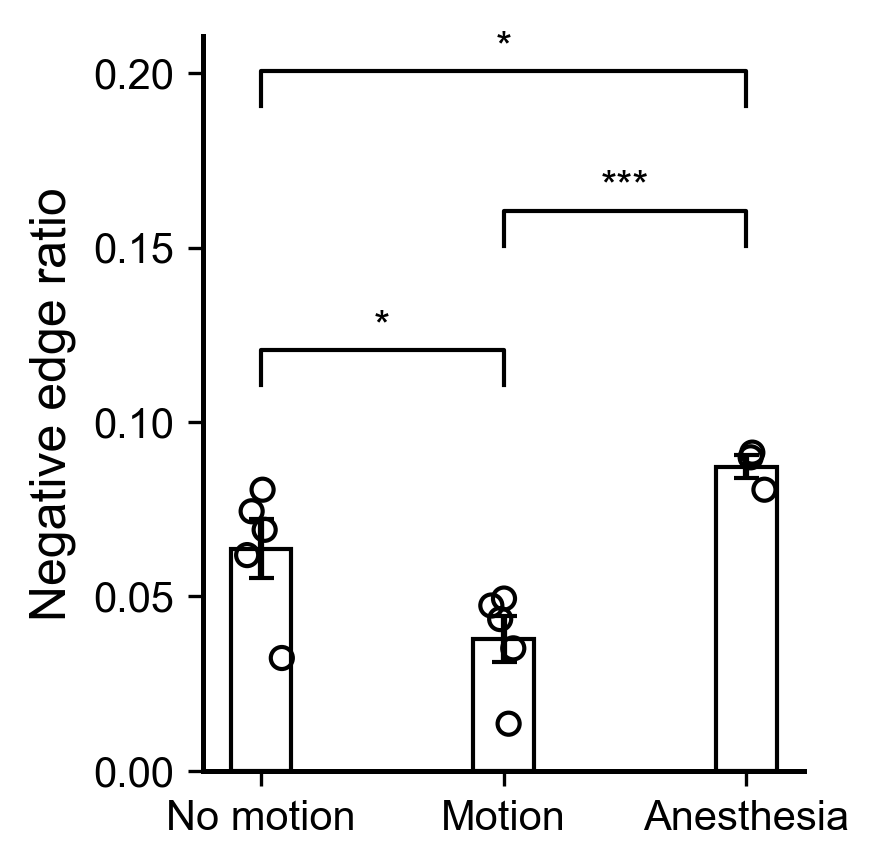

In [86]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42
})

def mean_sem(vals):
    vals = np.array(vals, float)
    vals = vals[np.isfinite(vals)]
    return vals.mean(), vals.std(ddof=1)/np.sqrt(len(vals))

def add_sig_line(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")
    if p < 0.001:
        text = "***"
    elif p < 0.01:
        text = "**"
    elif p < 0.05:
        text = "*"
    else:
        text = "n.s."
    ax.text((x1+x2)/2, y+h*1.1, text,
            ha='center', va='bottom')

fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

x = np.arange(len(states))

all_max = 0

for i, s in enumerate(states):
    vals = df[df["state"]==s]["neg_ratio_fdr"].dropna().values
    mean, sem = mean_sem(vals)

    ax.bar(i, mean, yerr=sem,
           capsize=3,width = 0.25,
           edgecolor="black",
           linewidth=1,facecolor = 'None')

    jitter = np.random.normal(0, 0.04, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter,
               vals,
               facecolors="none",
               edgecolors="black",
               s=28)

    all_max = max(all_max, mean + sem)

# Add significance bars
y_base = all_max + 0.02
h = 0.01

add_sig_line(ax, 0, 1, y_base, h, p_nm_m)
add_sig_line(ax, 1, 2, y_base + 0.04, h, p_m_a)
add_sig_line(ax, 0, 2, y_base + 0.08, h, p_nm_a)

ax.set_xticks(x)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
ax.set_ylabel("Negative edge ratio")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
# fig.savefig("negative_edge_ratio_with_stats.pdf", bbox_inches="tight")
plt.show()


### And scales

In [91]:

nodes = []
edges = []

for _, row in df.iterrows():
    n_nodes_active = row['n_nodes']
    n_edges = row['density_fdr'] * row['n_nodes'] * row['n_nodes'] // 2

    nodes.append(n_nodes_active)
    edges.append(n_edges)

df["n_nodes_fdr"] = nodes
df["n_edges_fdr"] = edges

In [92]:
from scipy.stats import f_oneway, ttest_ind

states = ["No_motion","Motion","Anesthesia"]

groups_nodes = [df[df["state"]==s]["n_nodes_fdr"].dropna() for s in states]
F_nodes, p_nodes = f_oneway(*groups_nodes)

print("Nodes ANOVA p =", p_nodes)


Nodes ANOVA p = 0.13272710927825018


In [93]:
groups_edges = [df[df["state"]==s]["n_edges_fdr"].dropna() for s in states]
F_edges, p_edges = f_oneway(*groups_edges)

print("Edges ANOVA p =", p_edges)


Edges ANOVA p = 0.6388361223172685


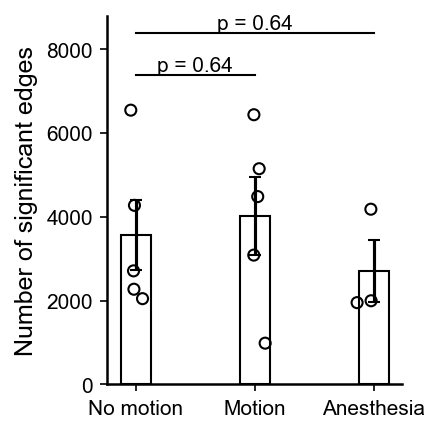

In [118]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42
})

def mean_sem(vals):
    vals = np.array(vals, float)
    vals = vals[np.isfinite(vals)]
    return vals.mean(), vals.std(ddof=1)/np.sqrt(len(vals))

fig, ax = plt.subplots(figsize=(3,3), dpi=150)

x = np.arange(len(states))

def add_sig_line(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")
    if p < 0.001:
        text = "***"
    elif p < 0.01:
        text = f"**p = {p}"
    elif p < 0.05:
        text = f"*p = {p}"
    else:
        text = f"p = {p:.2f}"
        # text = "n.s."
    ax.text((x1+x2)/2, y+h*1.1, text,
            ha='center', va='bottom')

all_max = 0
for i, s in enumerate(states):
    vals = df[df["state"]==s]["n_edges_fdr"].dropna().values
    mean, sem = mean_sem(vals)
    all_max = max(all_max, max(vals) + sem)
    ax.bar(i, mean, yerr=sem,width=0.25,
           capsize=3,facecolor="none",
           edgecolor="black",
           linewidth=1)

    jitter = np.random.normal(0,0.04,size=len(vals))
    ax.scatter(np.full(len(vals),i)+jitter,
               vals,
               facecolors="none",
               edgecolors="black",
               s=28)

ax.set_xticks(x)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
ax.set_ylabel("Number of significant edges")
y_base = all_max 
h = 0.01

add_sig_line(ax, 0, 1, y_base, h, p_edges)
# add_sig_line(ax, 1, 2, y_base + 0.04, h, p_edges)
add_sig_line(ax, 0, 2, y_base + 1000, h, p_edges)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig("validated_edges_by_state.pdf", bbox_inches="tight")
plt.show()


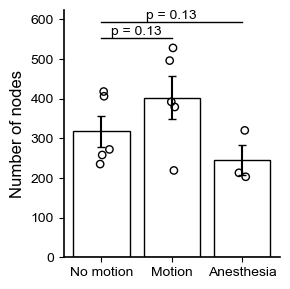

In [116]:
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42
})

fig, ax = plt.subplots(figsize=(3,3))
all_max = 0
for i, s in enumerate(states):
    vals = df[df["state"]==s]["n_nodes_fdr"].dropna().values
    mean, sem = mean_sem(vals)
    
    all_max = max(all_max, max(vals) + sem)

    ax.bar(i, mean, yerr=sem,
           capsize=3,facecolor="none",
           edgecolor="black",
           linewidth=1)

    jitter = np.random.normal(0,0.04,size=len(vals))
    ax.scatter(np.full(len(vals),i)+jitter,
               vals,
               facecolor="none",
               edgecolors="black",
               s=28)
y_base = all_max 
ax.set_xticks(x)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
ax.set_ylabel("Number of nodes")

add_sig_line(ax, 0, 1, y_base * 0.95, h, p_nodes)
# add_sig_line(ax, 1, 2, y_base + 0.04, h, p_edges)
add_sig_line(ax, 0, 2, y_base *1.02, h, p_nodes)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
# fig.savefig("validated_nodes_by_state.pdf", bbox_inches="tight")
plt.show()
